In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import scipy.io as sio
import torch
import torch.nn as nn
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.optim import Adam
from sklearn.decomposition import PCA

from src.dataset import DataGenerator, ESNDataset, partition_dataset
from src.function_calibration import calibrate, check_calibration
from src.functions_metrics import (
    combine_metrics_dictionaries,
    evaluate_metrics,
    evaluate_metrics_multiple,
    evaluate_metrics_qr,
    print_metrics,
)
from src.methods import ESNMCMC, ESNQR, CheckLoss, ESNVariational
from src.models import MLP, SSVS, BayesianModel, BayesianNeuralNetwork
from src.radial_plot import radial_plot
from src.reservoir import Reservoir
from src.visualization import (
    plot_calibrated_test,
    plot_functional_connectivity,
    plot_probabilistic_forecast,
)

ImportError: cannot import name 'plot_cal_test' from 'src.function_calibration' (/home/ubuntu/Bayesian-Inference-in-High-Dimensional-Reservoir-Dynamics-for-Neural-Time-Series/src/function_calibration.py)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Synthetic

In [3]:
time_steps = 25000
burnin_steps = 1000
stride = 10
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, _ = DataGenerator(time_steps, tau, n, beta, gamma, delta_t).generate_data()
X = X[burnin_steps::stride]
X += torch.randn(X.shape) * 0.3
X = X.float()

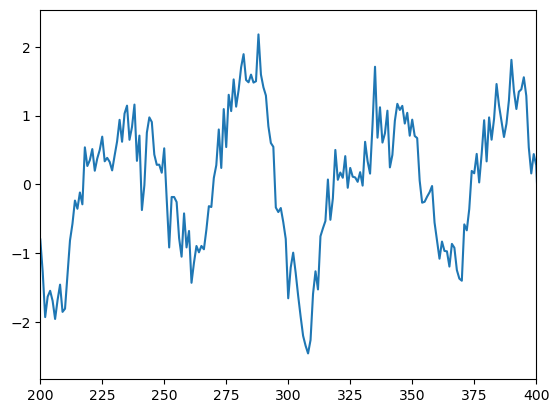

In [4]:
plt.plot(X)
plt.xlim(200, 400)
plt.show()

## Create the Reservoir

In [5]:
num_neurons_synth = 500
num_features_synth = X.shape[1]
reservoir_synth = Reservoir(
    input_features=num_features_synth, num_neurons=num_neurons_synth
)

## Generate the $(s,x)$ dataset

In [6]:
burnin_steps = 50
states_synth = torch.zeros((X.shape[0] - 1, num_neurons_synth))

for i, x in enumerate(X[:-1]):
    states_synth[i, :] = reservoir_synth(x)

reservoir_synth.reset_state()
dataset_synth = ESNDataset(states_synth[burnin_steps:-1], X[burnin_steps + 1 :])

In [7]:
train_set, cal_set, test_set = partition_dataset([dataset_synth], num_partitions=10)

In [8]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

## MCMC

We rely on Hamiltonian Monte Carlo methods in order to estimate the posterior distribution of $R$ (and $b$).
In particular we use the NUTS (No U-Turn Sampler) method, which is a variant of the standard HMC, that generally results in faster exploration of the parameter space.

Operatively we generate one or more Markov Chains, discarding the first `warmup_steps` samples from them.
The remaining samples of the parameters will be used to perform predictions on the test set, allowing us to give an estimation of the results.

In [ ]:
mcmc_model_synth = BayesianModel(
    in_features=num_neurons_synth, out_features=num_features_synth
).to(device)

In [ ]:
esn_mcmc = ESNMCMC(mcmc_model_synth)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/250 [00:00, ?it/s]

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

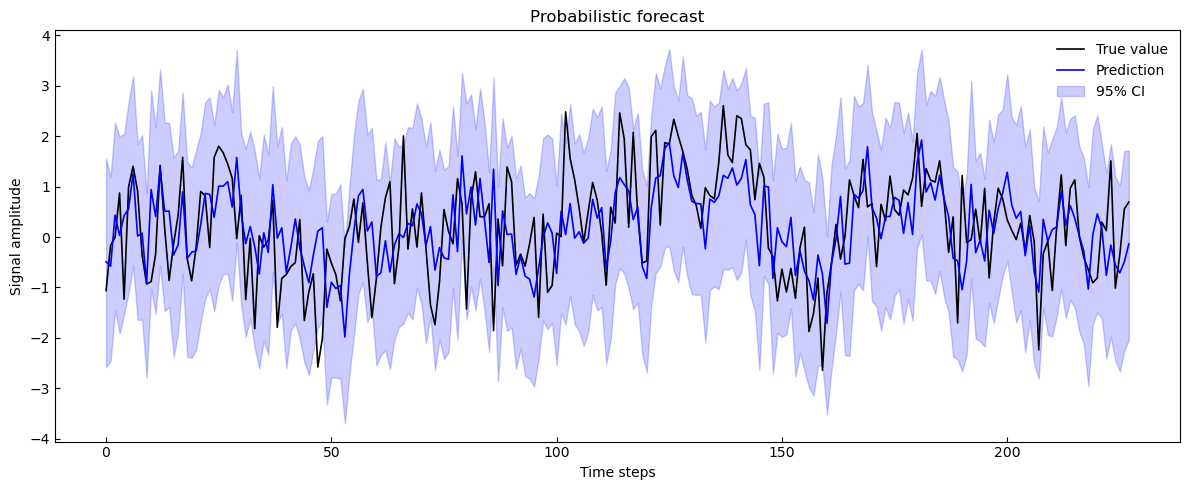

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

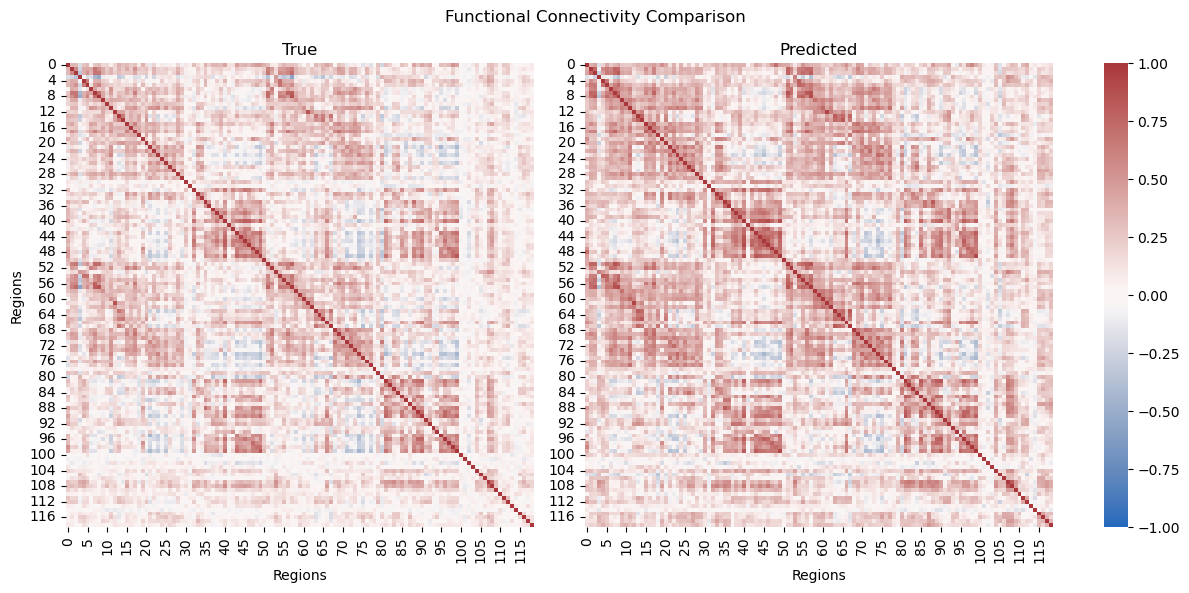

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc_synth = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set
)

Empirical Coverage: 0.944 ± 0.001
Calibration Error:  0.00076 ± 0.00006
mCRPS (Normalized): 0.0964 ± 0.0015
Width: 3.436 ± 0.045


### calibration algorithm

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

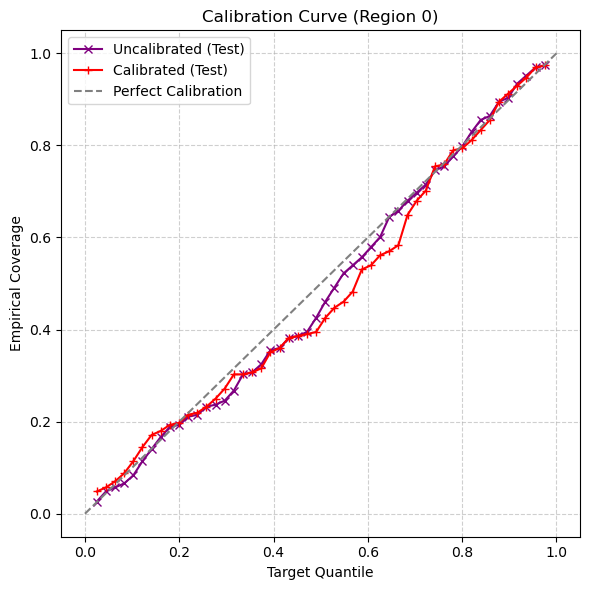

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.0812%
Mean MSCE (Calibrated Test): 0.1494%


In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

NameError: name 'torch' is not defined

## MCMC with PCA

Here we perform the same process as above, but with a Principal Component Analysis reduction applied to the reservoir state.

In [ ]:
n_components = 16
pca = PCA(n_components)

In [ ]:
# move datasets to cpu
train_set = train_set.to(torch.device("cpu"))
cal_set = cal_set.to(torch.device("cpu"))
test_set = test_set.to(torch.device("cpu"))

In [ ]:
# fit pca
pca = pca.fit(train_set.states.numpy())

In [ ]:
# apply pca to the sets
train_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(train_set.states.numpy())),
    x=train_set.x,
    mu=train_set.mu,
    std=train_set.mu,
    device=device,
)
cal_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(cal_set.states.numpy())),
    x=cal_set.x,
    mu=cal_set.mu,
    std=cal_set.mu,
    device=device,
)
test_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(test_set.states.numpy())),
    x=test_set.x,
    mu=test_set.mu,
    std=test_set.mu,
    device=device,
)

In [ ]:
mcmc_pca_model_synth = BayesianModel(
    in_features=n_components, out_features=num_features_synth
).to(device)

In [ ]:
esn_mcmc = ESNMCMC(mcmc_pca_model_synth)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_pca_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/250 [00:00, ?it/s]

In [ ]:
y_pred = esn_mcmc.predict(test_pca_set)
y_pred = y_pred.cpu()

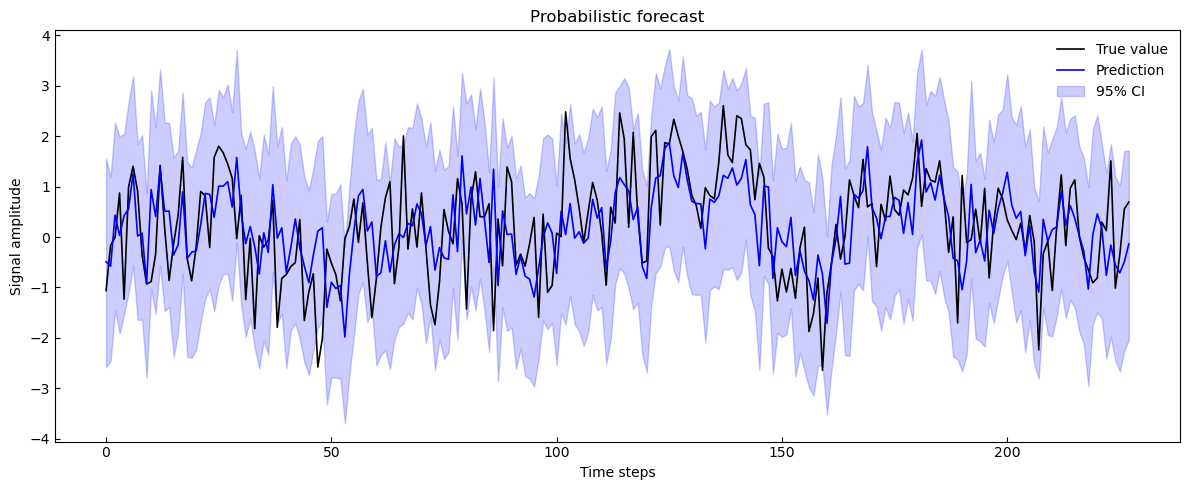

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

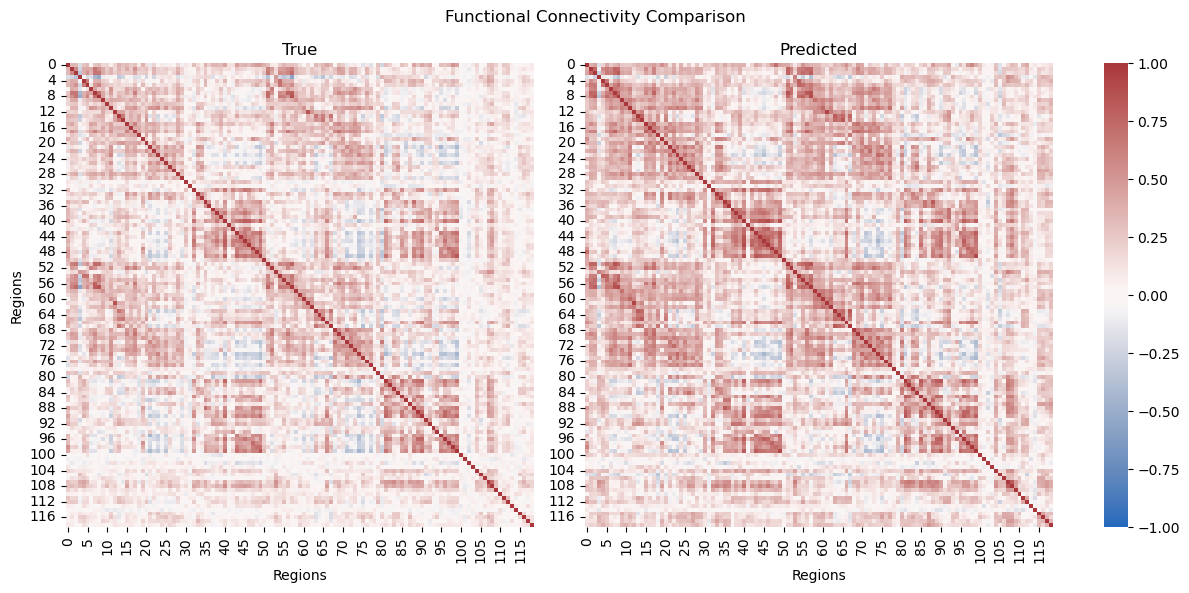

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc_pca_synth = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set
)

Empirical Coverage: 0.944 ± 0.001
Calibration Error:  0.00076 ± 0.00006
mCRPS (Normalized): 0.0964 ± 0.0015
Width: 3.436 ± 0.045


### calibration algorithm

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

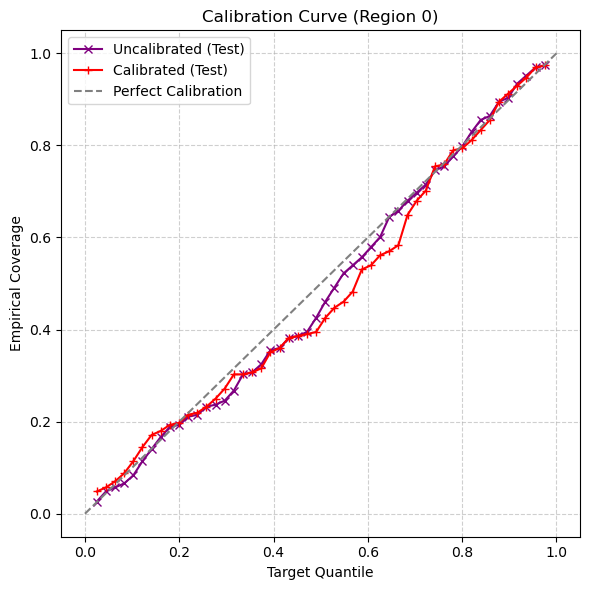

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.0812%
Mean MSCE (Calibrated Test): 0.1494%


In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

NameError: name 'torch' is not defined

## Bayesian Neural Network

A Bayesian Neural Network is a Neural Networks whose parameters are not set in stone (in evaluation time, at least), but instead they are sampled. 

In [ ]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

In [ ]:
layer_sizes = [
    num_neurons_synth,
    128,
    16,
    num_features_synth,
]
activation = nn.ReLU()
nn_model_synth = BayesianNeuralNetwork(
    layer_sizes, activation, sigma_bias=1.0, sigma_weight=16.0
).to(device)

In [ ]:
esn_mcmc = ESNMCMC(nn_model_synth)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 20
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/170 [00:00, ?it/s]

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

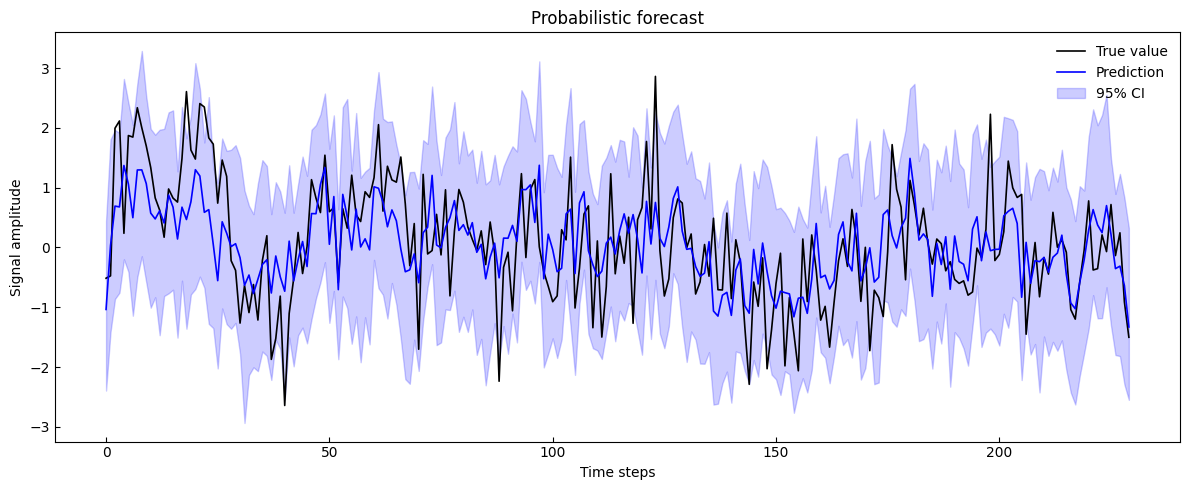

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

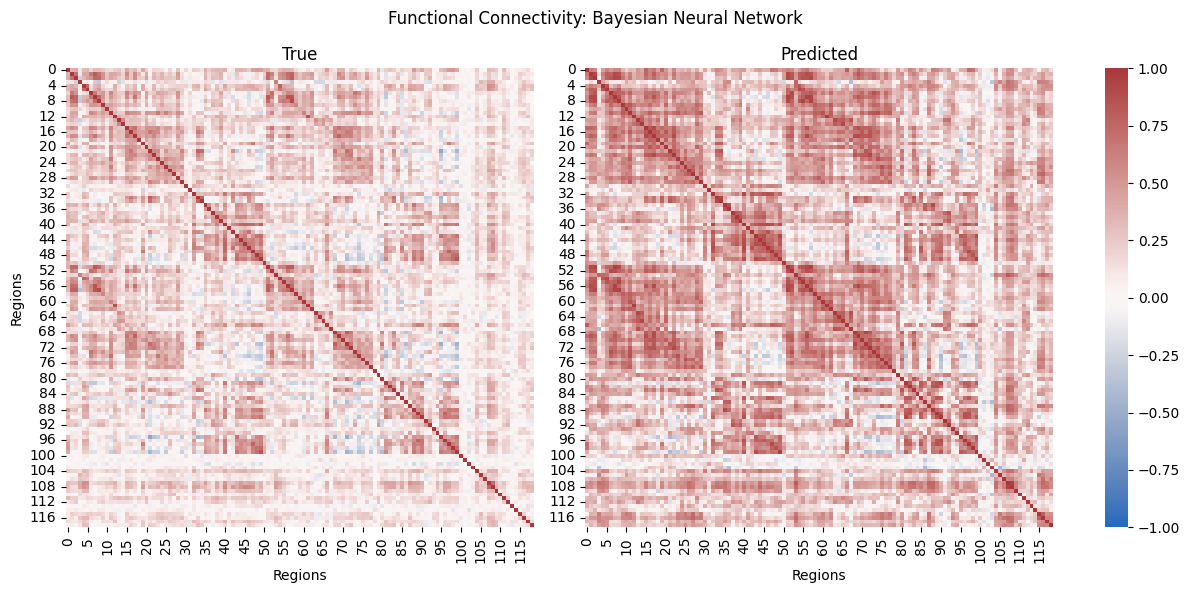

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_bnn_synth = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set, n_trials=1
)

Empirical Coverage: 0.876 ± 0.003
Calibration Error:  0.00242 ± 0.00017
mCRPS (Normalized): 0.1005 ± 0.0010
Width: 3.685 ± 0.033


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

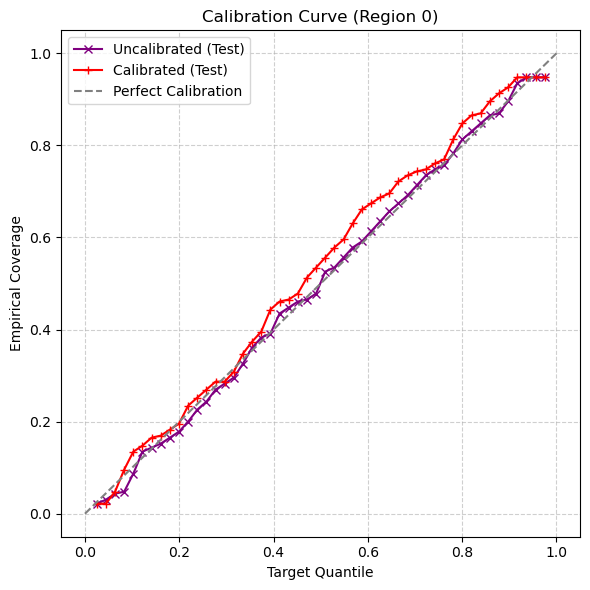

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.3052%
Mean MSCE (Calibrated Test): 0.2551%


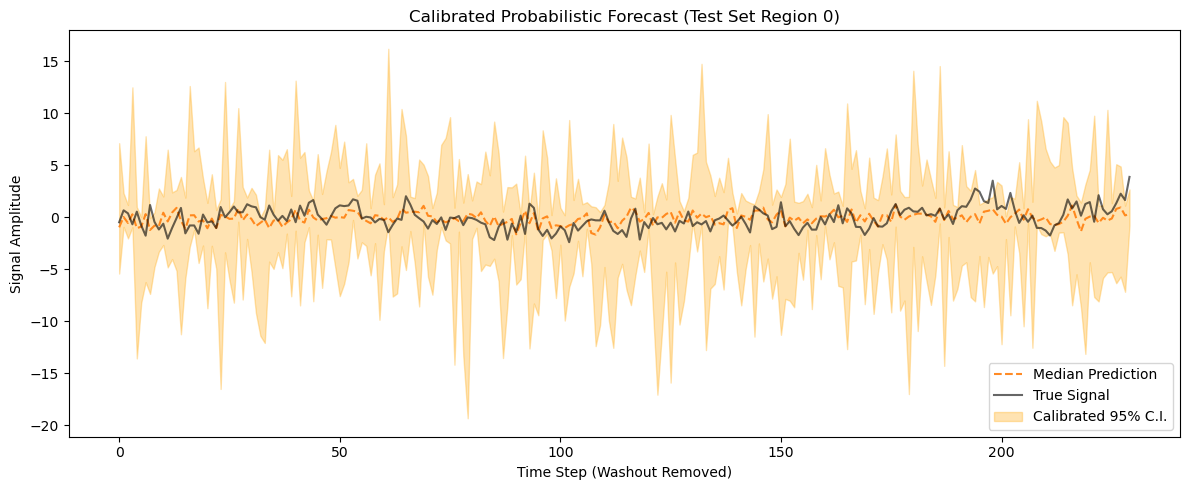

In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## SVI

In [ ]:
svi_model_synth = BayesianModel(
    in_features=num_neurons_synth, out_features=num_features_synth, scale=1.0
).to(device)

In [ ]:
# Setup Optimizer
LR = 0.0001
EPOCHS = 100

optimizer = Adam({"lr": LR})

In [ ]:
# PYRO GUIDE

RANK = int(np.sqrt(num_neurons_synth))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(svi_model_synth, rank=RANK)

In [ ]:
esn_var_synth = ESNVariational(
    svi_model_synth,
    guide,
    optimizer,
)

Training Pyro ESN:   0%|          | 1/400 [00:01<07:52,  1.18s/it, Loss=22194.7982]

Epoch 0 | Total ELBO Loss: 22194.7982


Training Pyro ESN:  25%|██▌       | 101/400 [00:27<01:17,  3.84it/s, Loss=8848.8895]

Epoch 100 | Total ELBO Loss: 8848.8895


Training Pyro ESN:  50%|█████     | 201/400 [00:53<00:51,  3.84it/s, Loss=5206.4527]

Epoch 200 | Total ELBO Loss: 5206.4527


Training Pyro ESN:  75%|███████▌  | 301/400 [01:20<00:27,  3.61it/s, Loss=3147.2196]

Epoch 300 | Total ELBO Loss: 3147.2196


Training Pyro ESN: 100%|██████████| 400/400 [01:48<00:00,  3.70it/s, Loss=1960.0415]


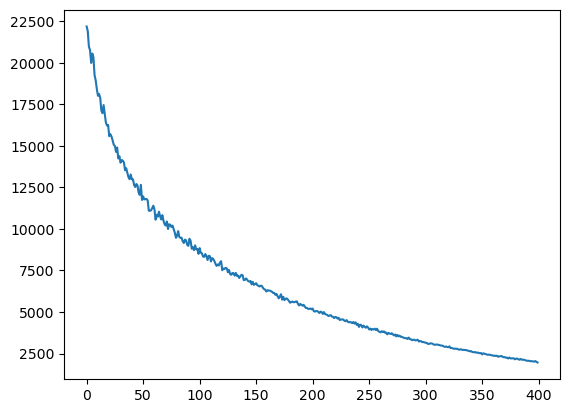

In [ ]:
loss_history = esn_var_synth.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [ ]:
y_pred = esn_var_synth.predict(test_set)
y_pred = y_pred.cpu()

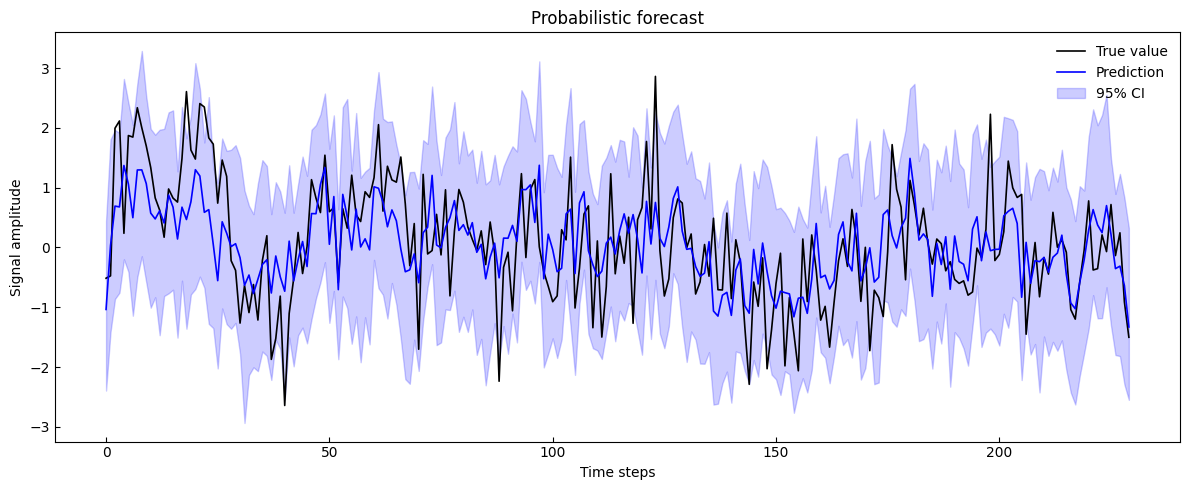

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

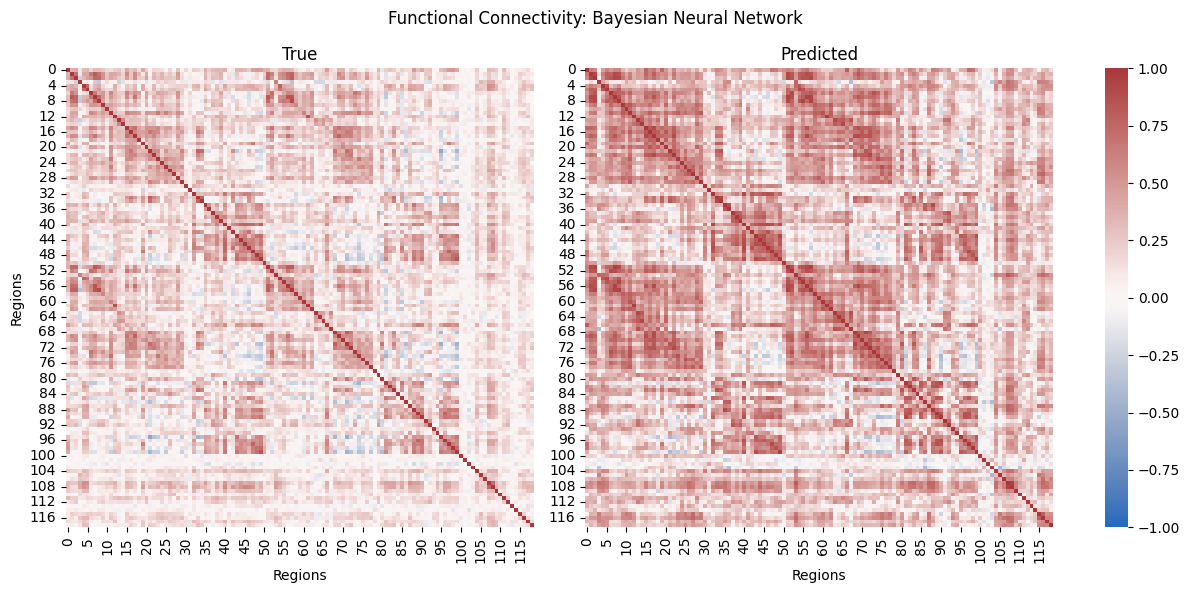

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_svi_synth = evaluate_metrics_multiple(
    esn_obj=esn_var_synth, y_true=test_set.x.cpu(), test_set=test_set, n_trials=1
)

Empirical Coverage: 0.619 ± 0.006
Calibration Error:  0.01723 ± 0.00046
mCRPS (Normalized): 0.0937 ± 0.0009
Width: 1.421 ± 0.014


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_var_synth.predict(cal_set)

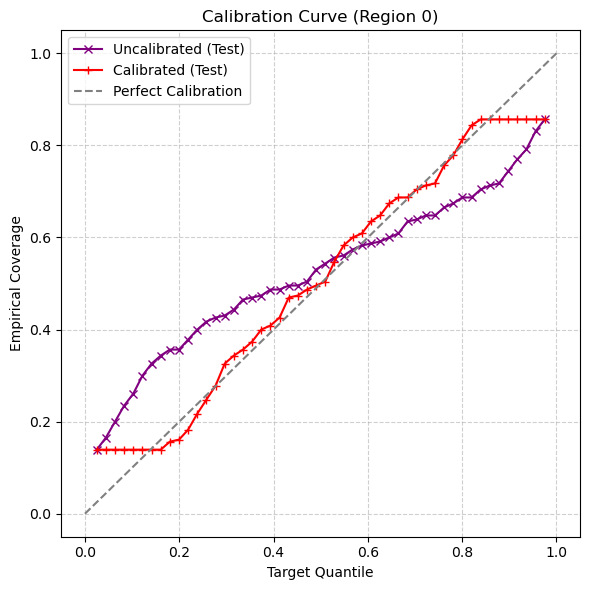

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 1.0509%
Mean MSCE (Calibrated Test): 0.3355%


In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## Stochastic search variable selection (SSVS)

Reservoir computing generates a high-dimensional state space containing hundreds of random features. Many of these features are irrelevant and can simply be interpreted as noise. Trying to learn all of them can slow down Bayesian inference algorithms like MCMC, a phenomenon related to the curse of dimensionality.

In order to try to work around this problem, we can implement the **Bayesian Stochastic Search Variable Selection (SSVS)** algorithm. The core idea is to introduce *sparsity* in the Reservoir parameter space by placing a "shrinking" prior (in our case, the **Horseshoe** prior) on the readout weights. 
This specific choice of prior actively shrinks the weights of useless nodes toward zero, focusing the MCMC sampling only on the most promising areas of the parameter space. 

In order to induce sparsity, the Horseshoe prior is implemented using a Half-Cauchy distribution $\mathcal{C}^{+}$:

* **Global Shrinkage:** $\tau \sim \mathcal{C}^{+}(0, 1)$
* **Local Shrinkage:** $\lambda_i \sim \mathcal{C}^{+}(0, 1)$
* **Reservoir Weights:** $\beta_i \sim \mathcal{N}(0, \lambda_i^2 \tau^2)$
* **Likelihood:** $y \sim \mathcal{N}(X\beta + b, \sigma^2)$

<p align="center">
  <img src="ssvs_horseshoe_prior_small.png" width="600">
</p>

Here, the Half-Cauchy distribution is specifically chosen for its sharp peak at zero and its heavy tails. The global parameter $\tau$ acts as a master threshold, aggressively shrinking all weights toward zero to suppress noise. Conversely, the local parameter $\lambda_i$ acts as an amplifier, allowing individual, highly relevant features to escape this global shrinkage and maintain large values.

While SSVS successfully solves the statistical curse of dimensionality by filtering out the noise and providing highly interpretable models, it introduces a new challenge. The hierarchical combination of $\tau$ and $\lambda_i$ creates a highly complex posterior geometry, known in literature as Neal's Funnel.
This causes the MCMC to be computationally slower than standard Bayesian Regression: gradient-based algorithms like NUTS are forced to take extremely small step sizes to correctly navigate this narrow probabilistic space without diverging, resulting in significantly longer training times.

In [ ]:
ssvs_model_synth = SSVS(num_neurons_synth, num_features_synth).to(device)

In [ ]:
esn_mcmc = ESNMCMC(ssvs_model_synth)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup:  14%|█▍        | 36/250 [01:01,  4.28s/it, step size=7.40e-04, acc. prob=0.773]

KeyboardInterrupt: 

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

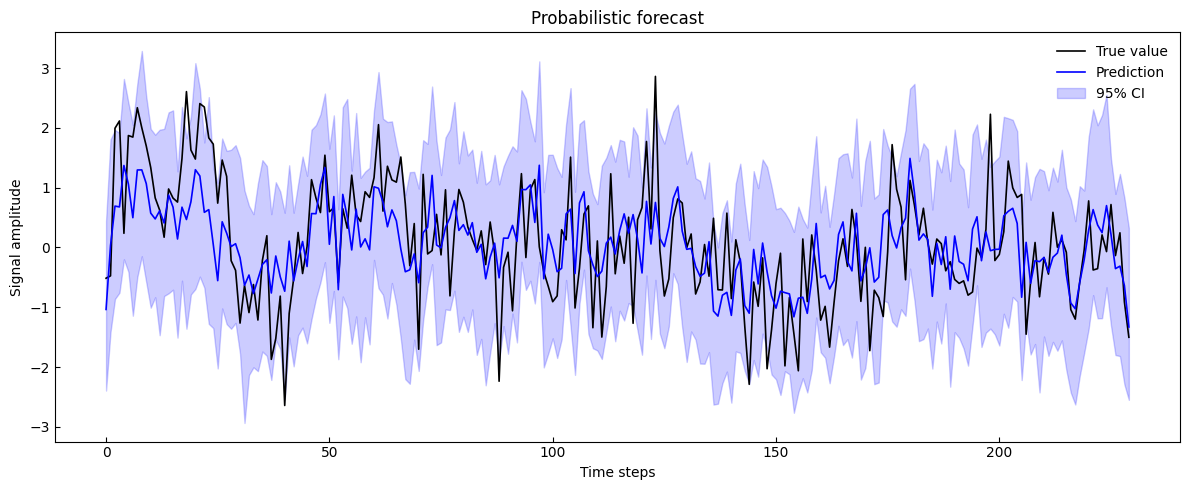

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

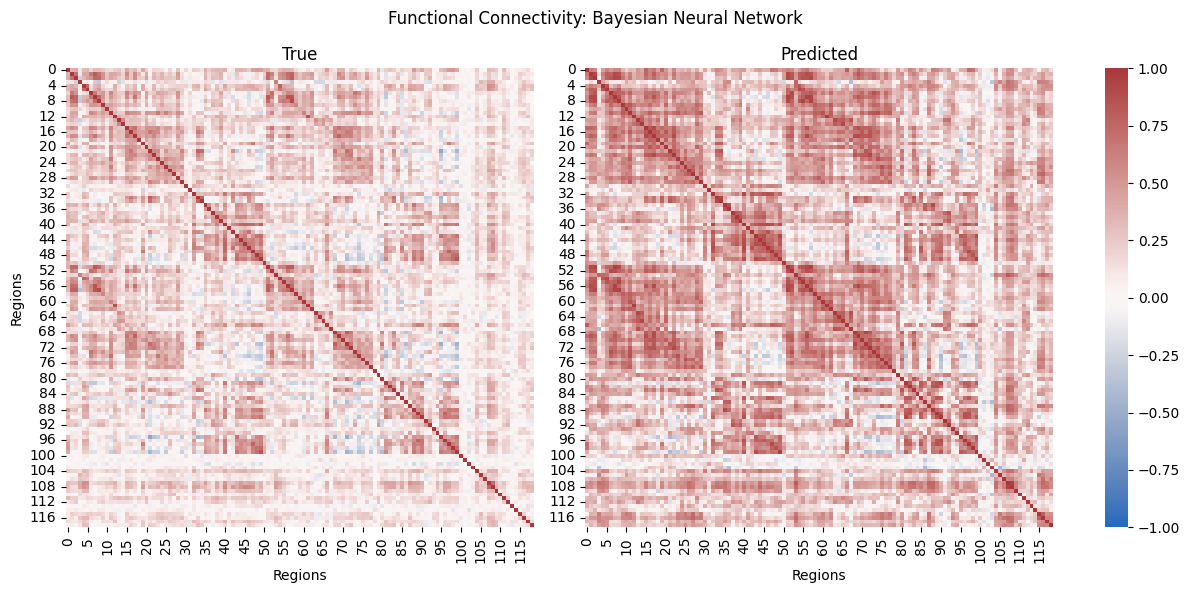

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_svss_synth = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set, n_trials=5
)

Empirical Coverage: 0.813 ± 0.004
Calibration Error:  0.00255 ± 0.00013
mCRPS (Normalized): 0.0892 ± 0.0011
Width: 2.490 ± 0.056


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

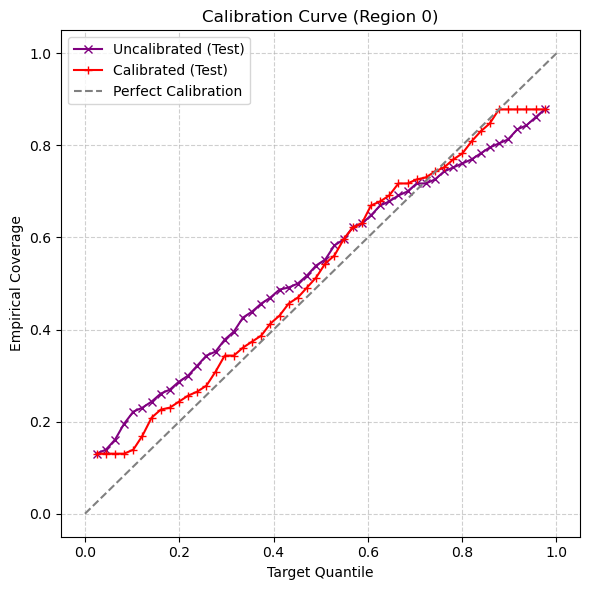

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.6025%
Mean MSCE (Calibrated Test): 0.2236%


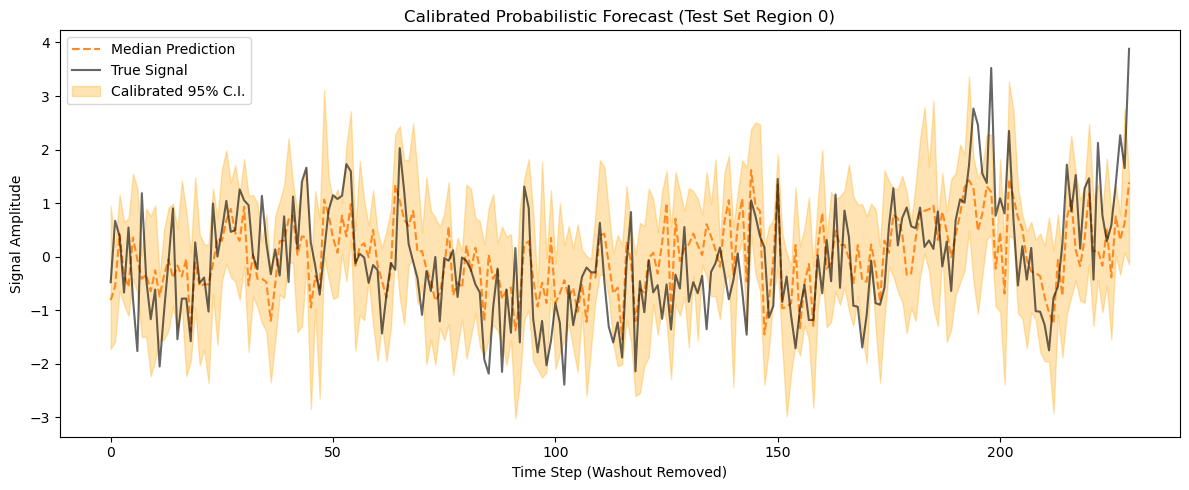

In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## QR

Instead of relying on Bayesian inference, the authors of the paper suggested that other, more efficient methods could be implemented. One of them is a **deterministic approach** known as **Quantile Regression (QR)**.

We wanted to test and compare this method to see whether it could outperform the previous inference-based approaches.

Instead of predicting the expected mean by minimizing the Mean Squared Error (MSE), QR trains the readout layer to predict specific *quantiles* of the target distribution. This completely bypasses the dimensionality issues of the Reservoir and directly generates calibrated confidence intervals in a fraction of the computational time.

In QR the optimization problem is not the "standard" one in which we minimize the sum of squared residuals, but it is modified as follows:

$$\arg\min_{R(\tau)} \sum_{t=1}^{T} \rho_\tau \left( y_t - g(s_t; R(\tau)) \right)$$

Where $\rho_\tau$ is the **Pinball Loss (or Check Loss)**:

$$\rho_\tau(r) = \tau \max(r, 0) + (1-\tau)\max(-r, 0)$$

and $r = y_{true} - y_{pred}$ is the residual. By simultaneously optimizing this loss for $\tau = \{0.025, 0.50, 0.975\}$, the network learns to output the median and the bounds for the $95\%$ Confidence Interval directly, being able to infer a more detailed view of the distribution $P(Y|S)$, than just its mean value.

In [ ]:
taus = [0.025, 0.25, 0.5, 0.75, 0.975]
# Calculate the exact output size needed (e.g., 119 * 5 = 595)
num_quantiles = len(taus)
out_features = num_features_synth * num_quantiles

# Update the linspace to target out_features
num_layers = 3
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_synth, out_features, num_layers)
]

# Instantiate the model with the correct dimensions
qr_model_synth = MLP(layer_dims, nn.Tanh()).to(device)

# Re-create your loss function and optimizer here...
loss_fn = CheckLoss(taus)
optimizer = torch.optim.Adam(qr_model_synth.parameters(), lr=0.001)

# Re-instantiate the wrapper
esn_qr = ESNQR(qr_model_synth, optimizer, loss_fn)

Training ESN:   1%|          | 3/400 [00:00<00:33, 12.01it/s, Loss=56.8759]

Epoch 0 | Total Loss: 60.3843


Training ESN:  26%|██▌       | 103/400 [00:07<00:20, 14.28it/s, Loss=24.6161]

Epoch 100 | Total Loss: 24.6369


Training ESN:  51%|█████     | 203/400 [00:14<00:13, 14.98it/s, Loss=24.2356]

Epoch 200 | Total Loss: 24.2431


Training ESN:  76%|███████▌  | 303/400 [00:20<00:06, 14.91it/s, Loss=23.6537]

Epoch 300 | Total Loss: 23.6741


Training ESN: 100%|██████████| 400/400 [00:27<00:00, 14.56it/s, Loss=22.7604]


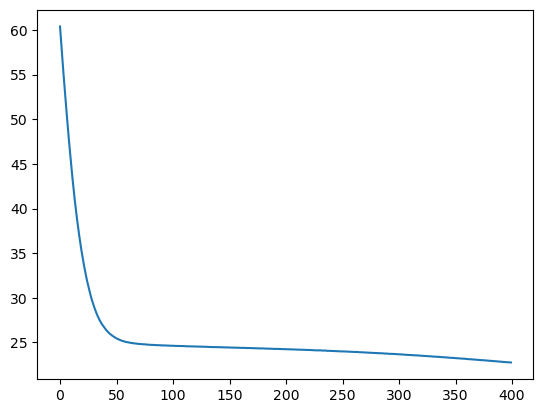

In [ ]:
EPOCHS = 400
loss_history = esn_qr.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [ ]:
y_pred = esn_qr.predict(test_set)
y_pred = y_pred.detach().cpu()

torch.Size([230, 5, 119])

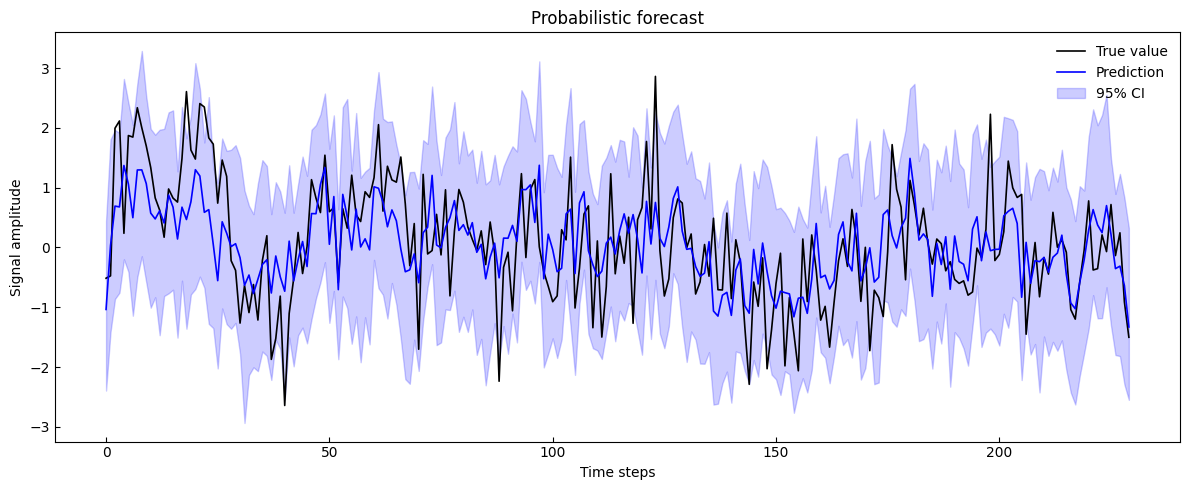

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

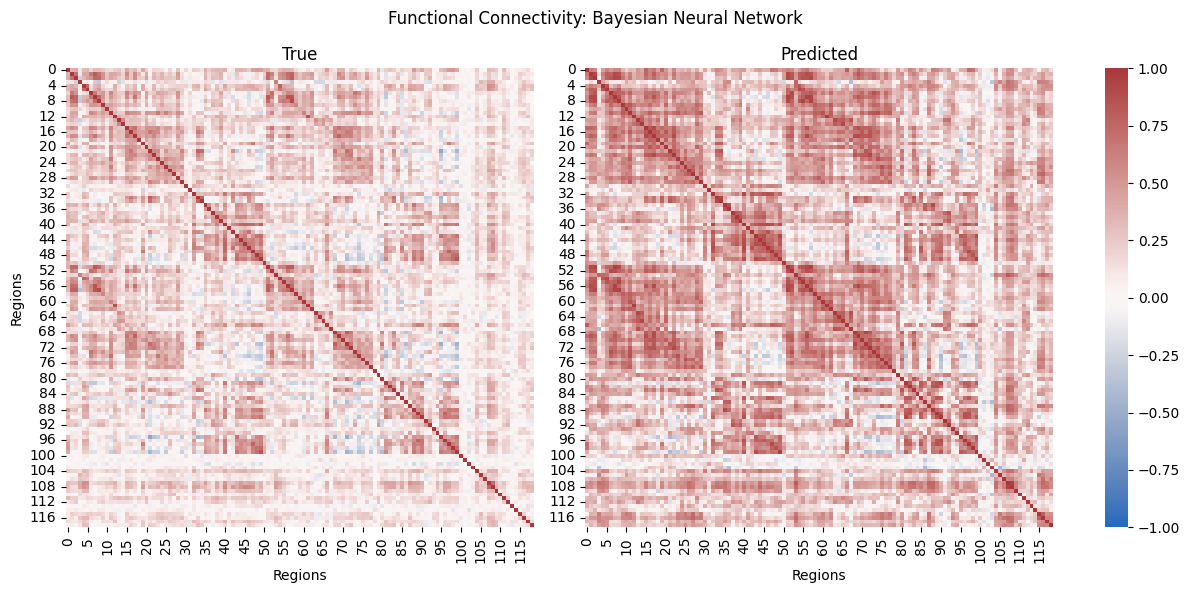

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics_qr(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_qr_synth = evaluate_metrics_multiple(
    esn_obj=esn_qr,
    y_true=test_set.x.cpu(),
    test_set=test_set,
    model_type="QR",
    tau_levels=taus,
)

Empirical Coverage: 0.934 ± 0.002
Calibration Error:  0.00128 ± 0.00012
mCRPS (Normalized): 0.0620 ± 0.0009
Width: 2.827 ± 0.027


## Radial plot dict

In [ ]:
# Pack calculated dictionaries together
all_calculated_results = {
    "MCMC": dict_mcmc_synth,
    "MCMC_PCA": dict_mcmc_pca_synth,
    "SVI": dict_svi_synth,
    "SSVS": dict_svss_synth,
    "QR": dict_qr_synth,
    "BNN": dict_bnn_synth,
}

# Run the merger function
dict_radial_plot = combine_metrics_dictionaries(all_calculated_results)

In [ ]:
radial_plot(dict_radial_plot)

{'Cal': {'MCMC': [0.0036944912280887365,
   0.0038016585167497396,
   0.0036905971355736256,
   0.003674107836559415,
   0.0037054489366710186],
  'MCMC_PCA': [0.002555210143327713,
   0.002546978183090687,
   0.0024578412994742393,
   0.0025873868726193905,
   0.0026526988949626684],
  'SVI': [0.009187371470034122],
  'SSVS': [0.002606029622256756,
   0.002605322515591979,
   0.002515411702916026,
   0.0025908940006047487,
   0.0026112671475857496],
  'QR': [0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009],
  'BNN': [0.002287723822519183,
   0.0024395454674959183,
   0.0024502198211848736,
   0.0025574329774826765,
   0.0024696746841073036]},
 'Cov': {'MCMC': [0.7809280753135681,
   0.7808914184570312,
   0.7823163866996765,
   0.781914472579956,
   0.7796127200126648],
  'MCMC_PCA': [0.8148337602615356,
   0.8108147978782654,
   0.8135185837745667,
   0.8139934539794922,
   0.8111435770988464],
  'SVI': [0.

# Real

In [5]:
# Load the MAT file for training and validation
rest1_file = sio.loadmat("./data/100307.REST1.LR.SchaeferS.ptseries.mat")
rest2_file = sio.loadmat("./data/100307.REST2.LR.SchaeferS.ptseries.mat")
data_rest1 = torch.from_numpy(rest1_file["tseries"]).float().t()
data_rest2 = torch.from_numpy(rest2_file["tseries"]).float().t()

In [6]:
mu1 = torch.mean(data_rest1, dim=0)
std1 = torch.std(data_rest1, dim=0)
mu2 = torch.mean(data_rest2, dim=0)
std2 = torch.std(data_rest2, dim=0)

data_rest1 = (data_rest1 - mu1) / std1
data_rest2 = (data_rest2 - mu2) / std2

## Create the Reservoir

In [7]:
num_neurons_real = 500
num_features_real = data_rest1.shape[1]
reservoir_real = Reservoir(
    input_features=num_features_real, num_neurons=num_neurons_real
)

## Generate the $(s,x)$ dataset

In [10]:
burnin_steps = 50
states_rest1 = torch.zeros((data_rest1.shape[0] - 1, num_neurons_real))
states_rest2 = torch.zeros((data_rest2.shape[0] - 1, num_neurons_real))

for i, x in enumerate(data_rest1[:-1]):
    states_rest1[i, :] = reservoir_real(x)

reservoir_real.reset_state()

for i, x in enumerate(data_rest2[:-1]):
    states_rest2[i, :] = reservoir_real(x)

dataset_rest1 = ESNDataset(
    states_rest1[burnin_steps:-1], data_rest1[burnin_steps + 1 :], mu1, std1
)
dataset_rest2 = ESNDataset(
    states_rest2[burnin_steps:-1], data_rest2[burnin_steps + 1 :], mu2, std2
)

In [11]:
train_set, cal_set, test_set = partition_dataset([dataset_rest1, dataset_rest2])

In [12]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

## MCMC

We rely on Hamiltonian Monte Carlo methods in order to estimate the posterior distribution of $R$ (and $b$).
In particular we use the NUTS (No U-Turn Sampler) method, which is a variant of the standard HMC, that generally results in faster exploration of the parameter space.

Operatively we generate one or more Markov Chains, discarding the first `warmup_steps` samples from them.
The remaining samples of the parameters will be used to perform predictions on the test set, allowing us to give an estimation of the results.

In [14]:
mcmc_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [15]:
esn_mcmc = ESNMCMC(mcmc_model_real)

In [16]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/250 [00:00, ?it/s]

In [17]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

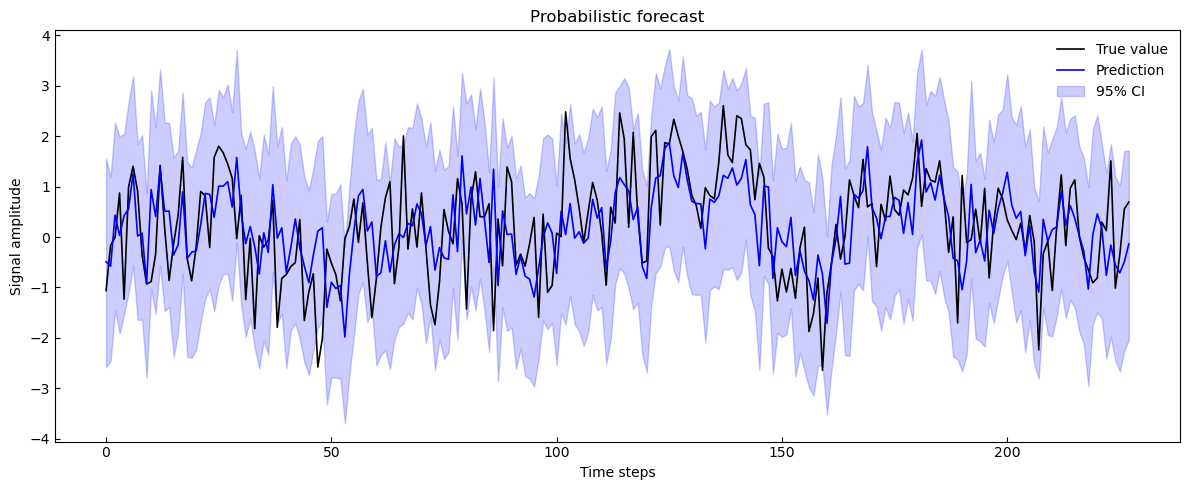

In [18]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

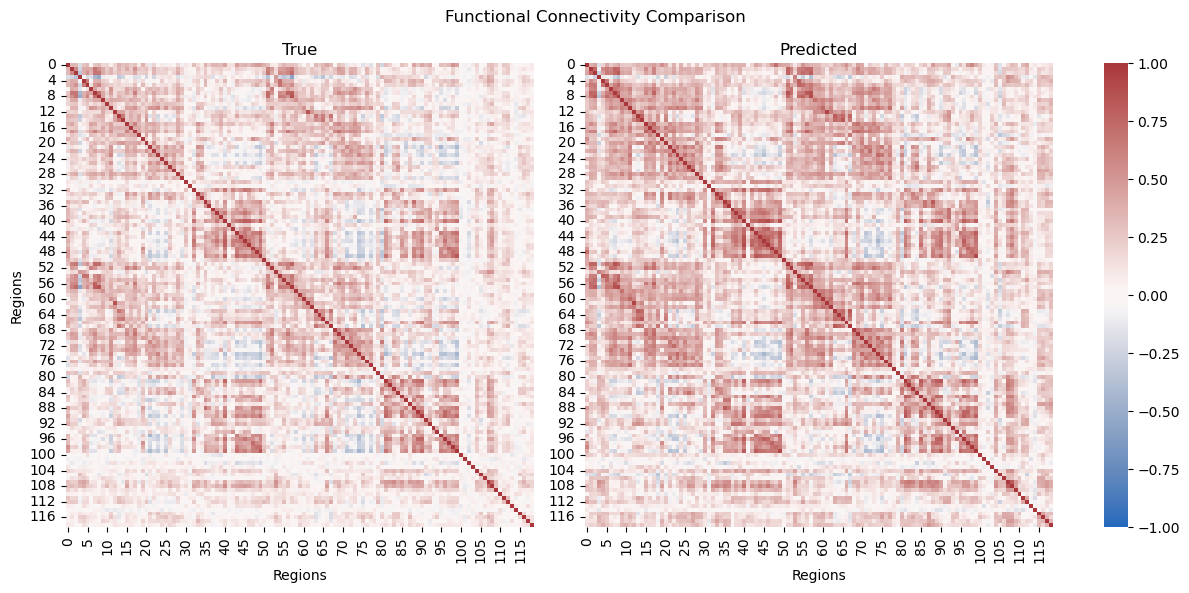

In [19]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc_real = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set
)

Empirical Coverage: 0.944 ± 0.001
Calibration Error:  0.00076 ± 0.00006
mCRPS (Normalized): 0.0964 ± 0.0015
Width: 3.436 ± 0.045


### calibration algorithm

In [21]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [22]:
y_pred_cal = esn_mcmc.predict(cal_set)

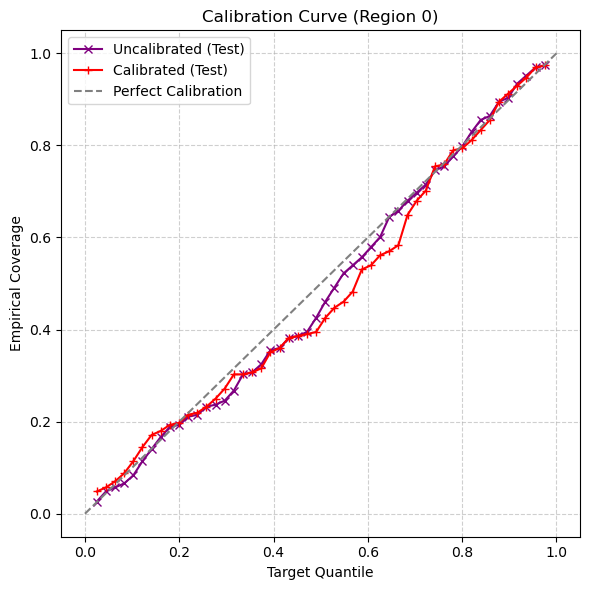

In [23]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [24]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.0812%
Mean MSCE (Calibrated Test): 0.1494%


In [25]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

NameError: name 'torch' is not defined

## MCMC with PCA

Here we perform the same process as above, but with a Principal Component Analysis reduction applied to the reservoir state.

In [ ]:
n_components = 16
pca = PCA(n_components)

In [15]:
# move datasets to cpu
train_set = train_set.to(torch.device("cpu"))
cal_set = cal_set.to(torch.device("cpu"))
test_set = test_set.to(torch.device("cpu"))

In [16]:
# fit pca
pca = pca.fit(train_set.states.numpy())

In [17]:
# apply pca to the sets
train_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(train_set.states.numpy())),
    x=train_set.x,
    mu=train_set.mu,
    std=train_set.mu,
    device=device,
)
cal_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(cal_set.states.numpy())),
    x=cal_set.x,
    mu=cal_set.mu,
    std=cal_set.mu,
    device=device,
)
test_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(test_set.states.numpy())),
    x=test_set.x,
    mu=test_set.mu,
    std=test_set.mu,
    device=device,
)

In [18]:
mcmc_pca_model_real = BayesianModel(
    in_features=n_components, out_features=num_features_real
).to(device)

In [19]:
esn_mcmc = ESNMCMC(mcmc_pca_model_real)

In [20]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_pca_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/250 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/250 [00:00, ?it/s]

In [21]:
y_pred = esn_mcmc.predict(test_pca_set)
y_pred = y_pred.cpu()

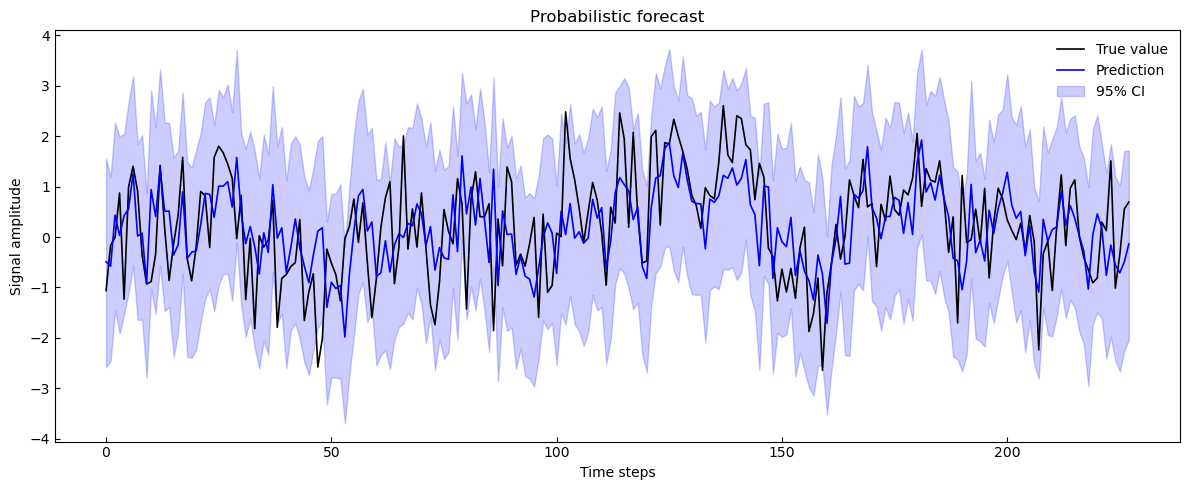

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

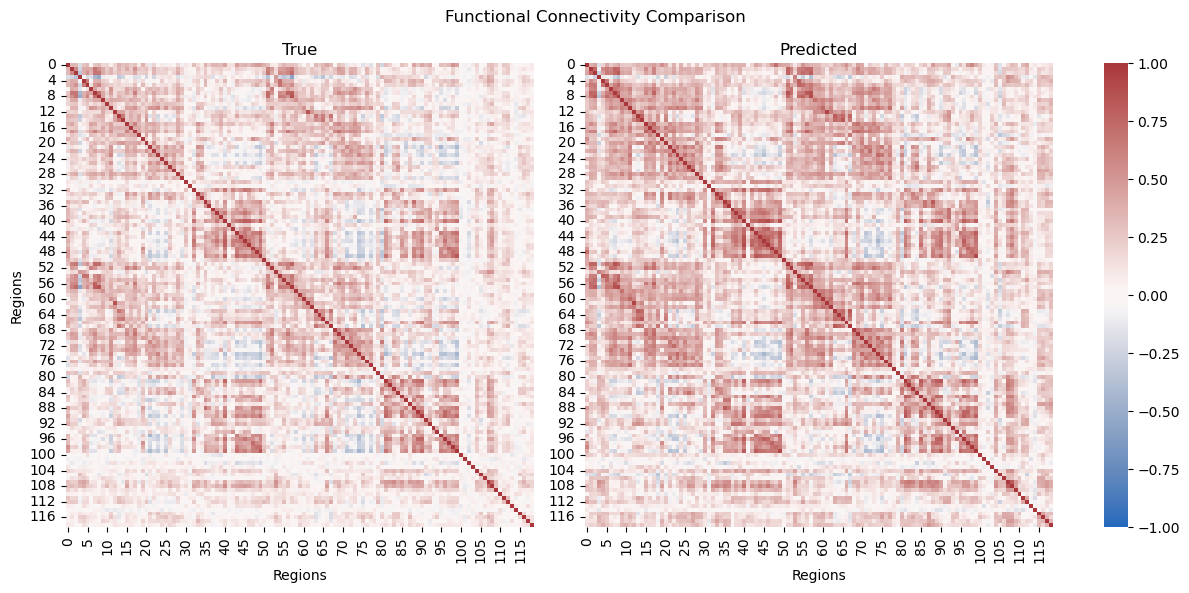

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc_pca_real = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set
)

Empirical Coverage: 0.944 ± 0.001
Calibration Error:  0.00076 ± 0.00006
mCRPS (Normalized): 0.0964 ± 0.0015
Width: 3.436 ± 0.045


### calibration algorithm

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

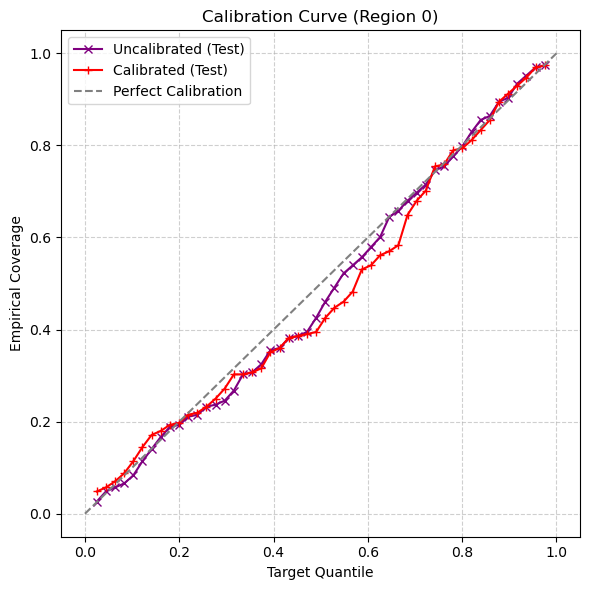

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.0812%
Mean MSCE (Calibrated Test): 0.1494%


In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

NameError: name 'torch' is not defined

## Bayesian Neural Network

A Bayesian Neural Network is a Neural Networks whose parameters are not set in stone (in evaluation time, at least), but instead they are sampled. 

In [ ]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

In [ ]:
layer_sizes = [
    num_neurons_real,
    128,
    16,
    num_features_real,
]
activation = nn.ReLU()
nn_model_real = BayesianNeuralNetwork(
    layer_sizes, activation, sigma_bias=1.0, sigma_weight=16.0
).to(device)

In [ ]:
esn_mcmc = ESNMCMC(nn_model_real)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 20
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [3]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [4]:   0%|          | 0/170 [00:00, ?it/s]

Warmup [5]:   0%|          | 0/170 [00:00, ?it/s]

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

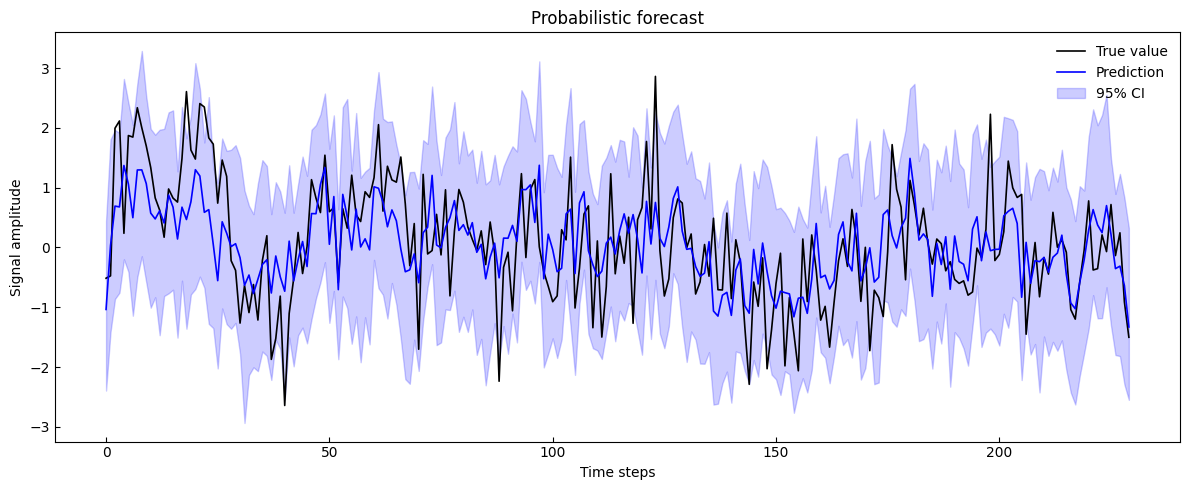

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

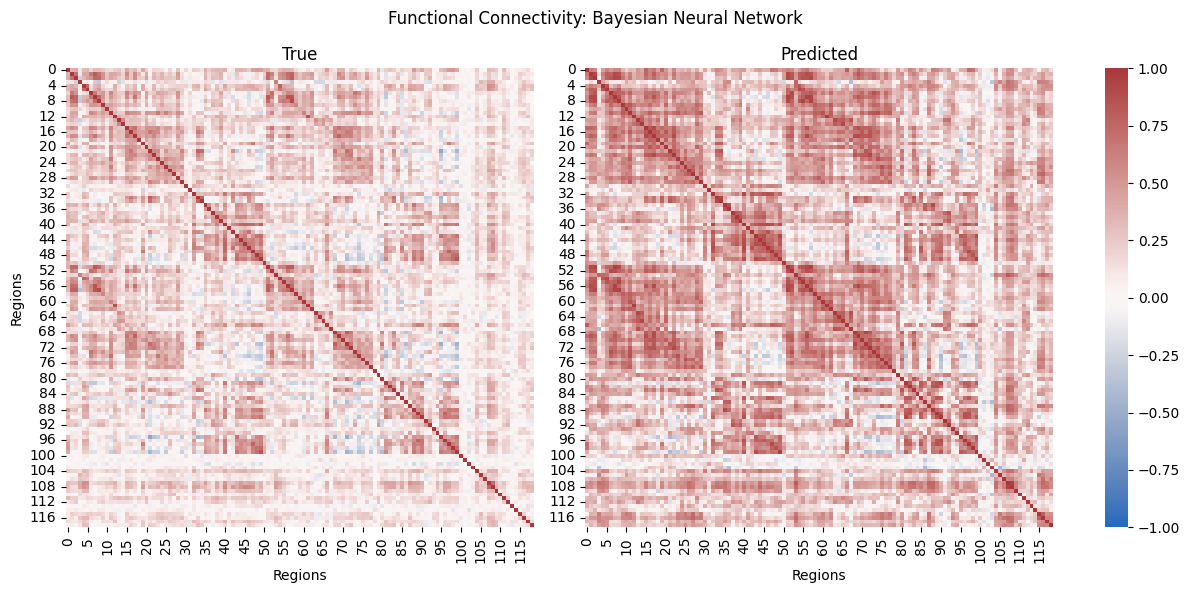

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_bnn_real = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set, n_trials=1
)

Empirical Coverage: 0.876 ± 0.003
Calibration Error:  0.00242 ± 0.00017
mCRPS (Normalized): 0.1005 ± 0.0010
Width: 3.685 ± 0.033


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

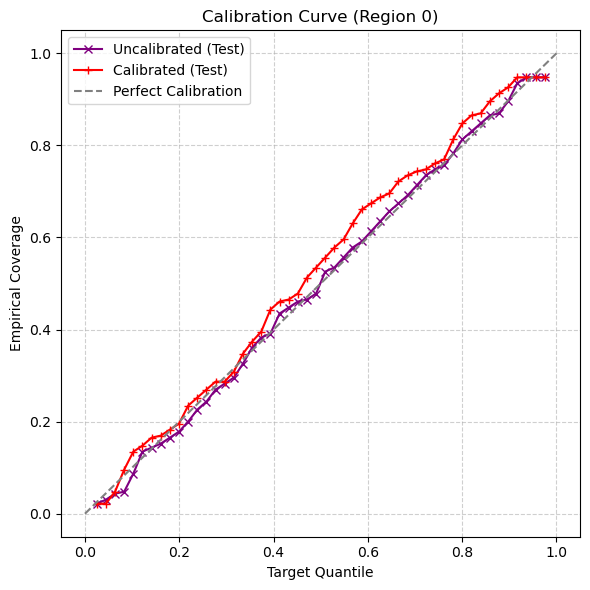

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.3052%
Mean MSCE (Calibrated Test): 0.2551%


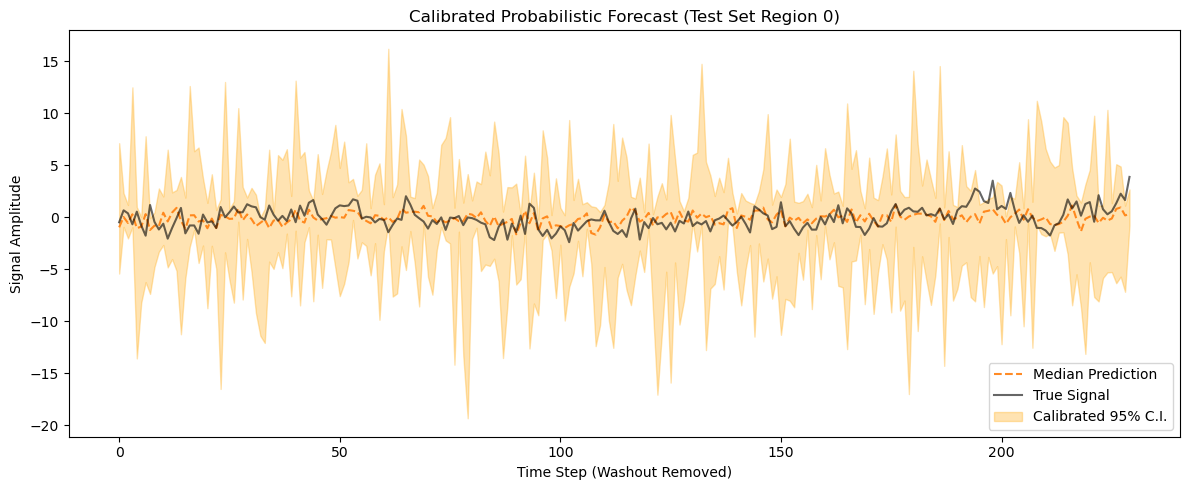

In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## SVI

In [ ]:
svi_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real, scale=1.0
).to(device)

In [ ]:
# Setup Optimizer
LR = 0.0001
EPOCHS = 100

optimizer = Adam({"lr": LR})

In [26]:
# PYRO GUIDE

RANK = int(np.sqrt(num_neurons_real))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(svi_model_real, rank=RANK)

In [27]:
esn_var_real = ESNVariational(
    svi_model_real,
    guide,
    optimizer,
)

Training Pyro ESN:   0%|          | 1/400 [00:01<07:52,  1.18s/it, Loss=22194.7982]

Epoch 0 | Total ELBO Loss: 22194.7982


Training Pyro ESN:  25%|██▌       | 101/400 [00:27<01:17,  3.84it/s, Loss=8848.8895]

Epoch 100 | Total ELBO Loss: 8848.8895


Training Pyro ESN:  50%|█████     | 201/400 [00:53<00:51,  3.84it/s, Loss=5206.4527]

Epoch 200 | Total ELBO Loss: 5206.4527


Training Pyro ESN:  75%|███████▌  | 301/400 [01:20<00:27,  3.61it/s, Loss=3147.2196]

Epoch 300 | Total ELBO Loss: 3147.2196


Training Pyro ESN: 100%|██████████| 400/400 [01:48<00:00,  3.70it/s, Loss=1960.0415]


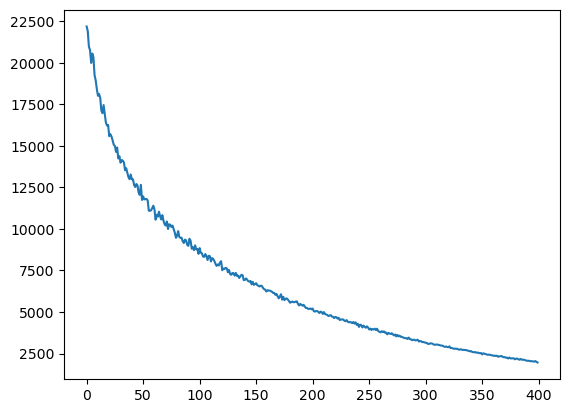

In [28]:
loss_history = esn_var_real.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [29]:
y_pred = esn_var_real.predict(test_set)
y_pred = y_pred.cpu()

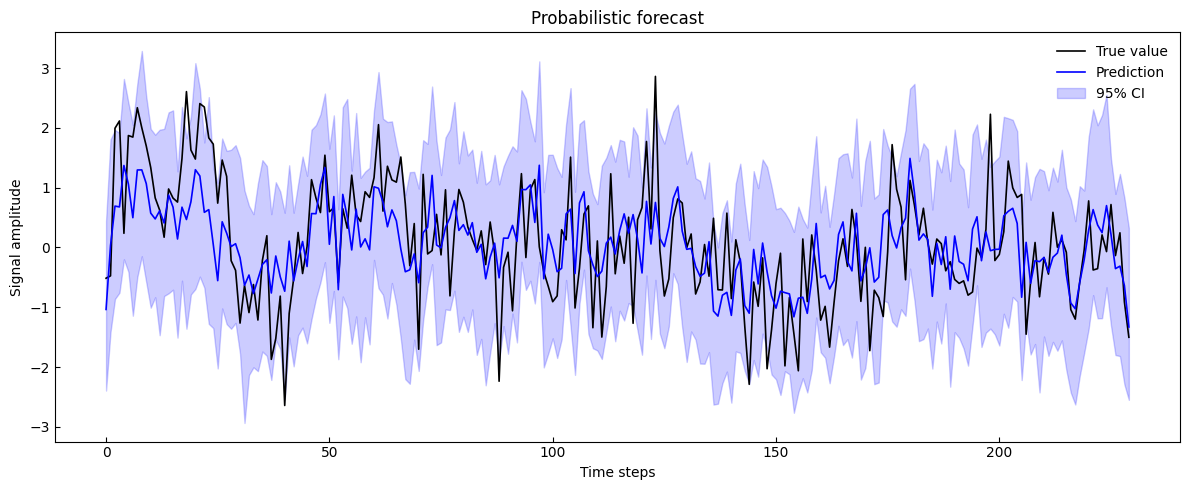

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

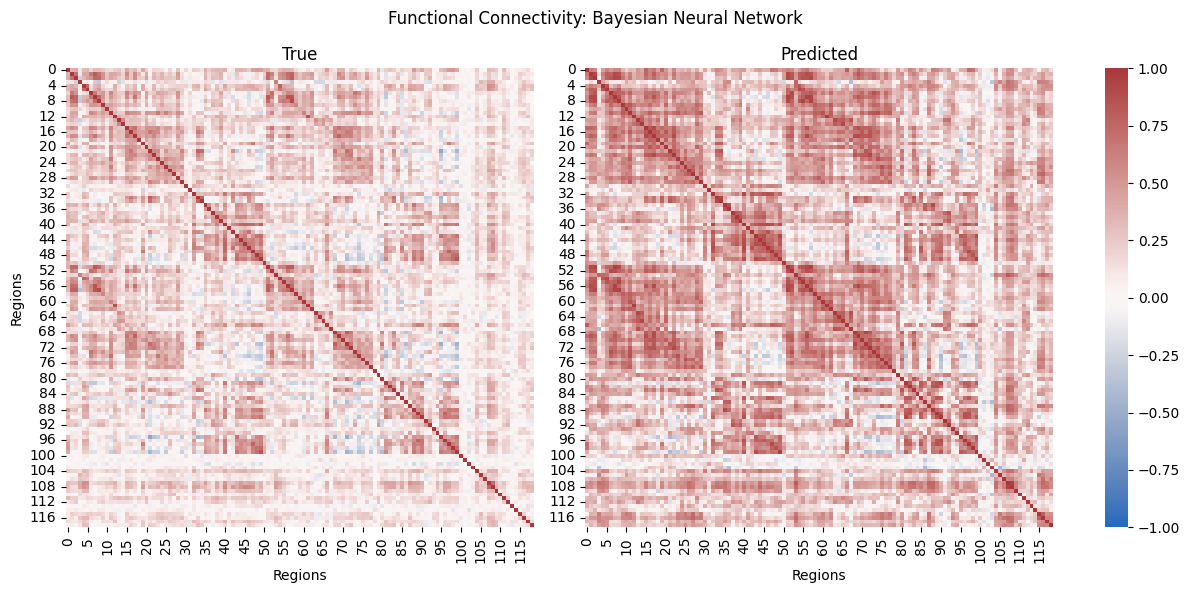

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_svi_real = evaluate_metrics_multiple(
    esn_obj=esn_var_real, y_true=test_set.x.cpu(), test_set=test_set, n_trials=1
)

Empirical Coverage: 0.619 ± 0.006
Calibration Error:  0.01723 ± 0.00046
mCRPS (Normalized): 0.0937 ± 0.0009
Width: 1.421 ± 0.014


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_var_real.predict(cal_set)

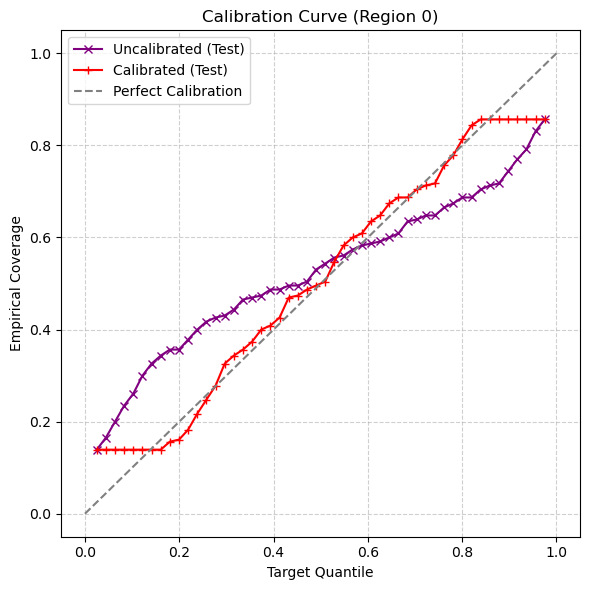

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 1.0509%
Mean MSCE (Calibrated Test): 0.3355%


In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## Stochastic search variable selection (SSVS)

Reservoir computing generates a high-dimensional state space containing hundreds of random features. Many of these features are irrelevant and can simply be interpreted as noise. Trying to learn all of them can slow down Bayesian inference algorithms like MCMC, a phenomenon related to the curse of dimensionality.

In order to try to work around this problem, we can implement the **Bayesian Stochastic Search Variable Selection (SSVS)** algorithm. The core idea is to introduce *sparsity* in the Reservoir parameter space by placing a "shrinking" prior (in our case, the **Horseshoe** prior) on the readout weights. 
This specific choice of prior actively shrinks the weights of useless nodes toward zero, focusing the MCMC sampling only on the most promising areas of the parameter space. 

In order to induce sparsity, the Horseshoe prior is implemented using a Half-Cauchy distribution $\mathcal{C}^{+}$:

* **Global Shrinkage:** $\tau \sim \mathcal{C}^{+}(0, 1)$
* **Local Shrinkage:** $\lambda_i \sim \mathcal{C}^{+}(0, 1)$
* **Reservoir Weights:** $\beta_i \sim \mathcal{N}(0, \lambda_i^2 \tau^2)$
* **Likelihood:** $y \sim \mathcal{N}(X\beta + b, \sigma^2)$

<p align="center">
  <img src="ssvs_horseshoe_prior_small.png" width="600">
</p>

Here, the Half-Cauchy distribution is specifically chosen for its sharp peak at zero and its heavy tails. The global parameter $\tau$ acts as a master threshold, aggressively shrinking all weights toward zero to suppress noise. Conversely, the local parameter $\lambda_i$ acts as an amplifier, allowing individual, highly relevant features to escape this global shrinkage and maintain large values.

While SSVS successfully solves the statistical curse of dimensionality by filtering out the noise and providing highly interpretable models, it introduces a new challenge. The hierarchical combination of $\tau$ and $\lambda_i$ creates a highly complex posterior geometry, known in literature as Neal's Funnel.
This causes the MCMC to be computationally slower than standard Bayesian Regression: gradient-based algorithms like NUTS are forced to take extremely small step sizes to correctly navigate this narrow probabilistic space without diverging, resulting in significantly longer training times.

In [9]:
ssvs_model_real = SSVS(num_neurons_real, num_features_real).to(device)

In [10]:
esn_mcmc = ESNMCMC(ssvs_model_real)

In [ ]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup:  14%|█▍        | 36/250 [01:01,  4.28s/it, step size=7.40e-04, acc. prob=0.773]

KeyboardInterrupt: 

In [ ]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

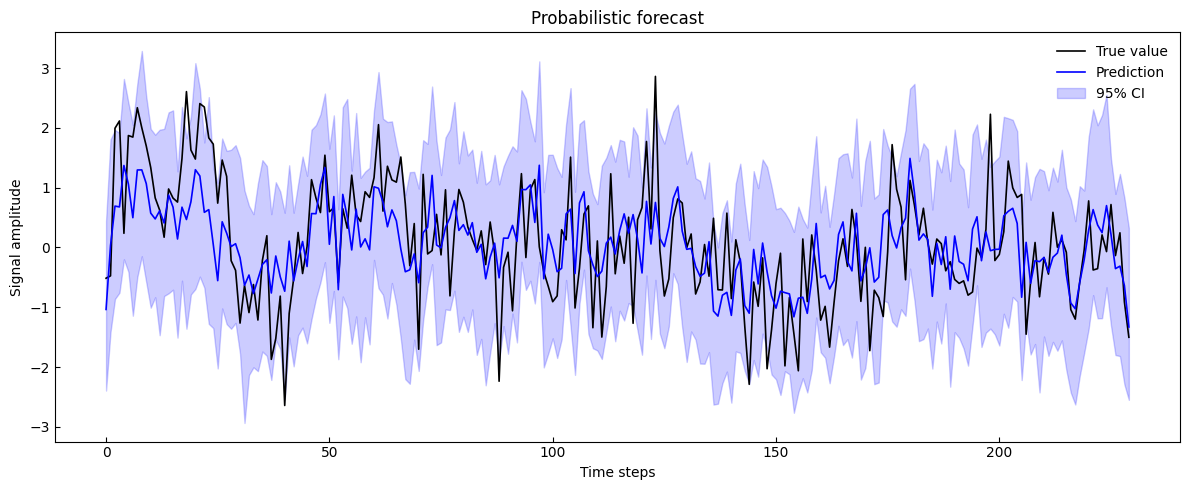

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

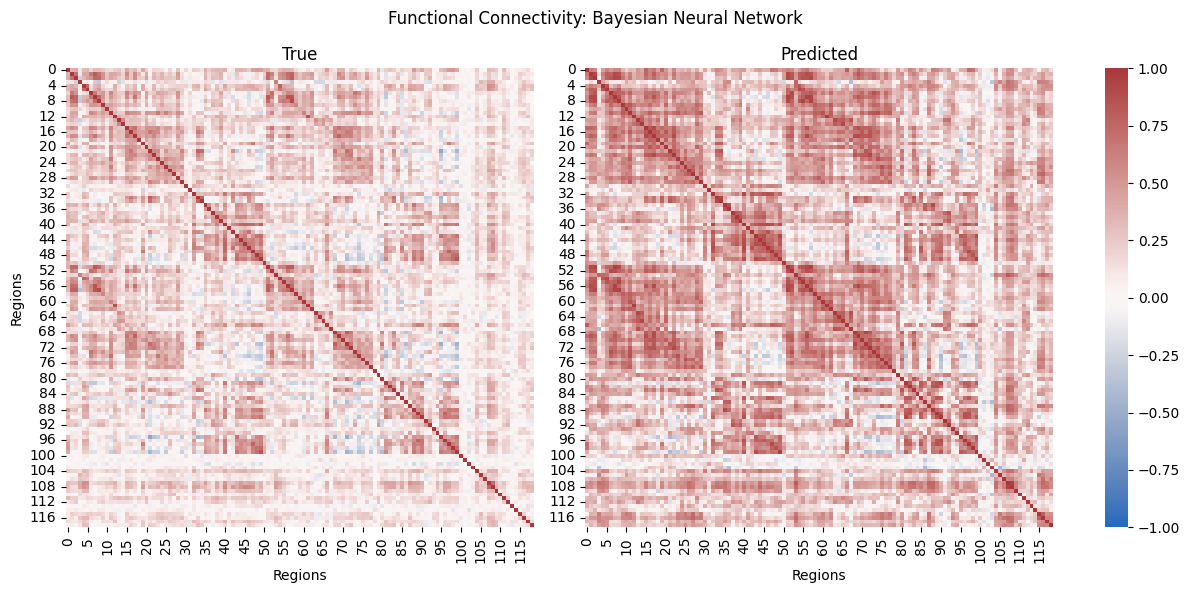

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_svss_real = evaluate_metrics_multiple(
    esn_obj=esn_mcmc, y_true=test_set.x.cpu(), test_set=test_set, n_trials=5
)

Empirical Coverage: 0.813 ± 0.004
Calibration Error:  0.00255 ± 0.00013
mCRPS (Normalized): 0.0892 ± 0.0011
Width: 2.490 ± 0.056


### calibration

In [ ]:
robust_quantiles = np.linspace(0.025, 0.975, 50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy()
Y_cal_array = cal_set.x.cpu().numpy()

In [ ]:
y_pred_cal = esn_mcmc.predict(cal_set)

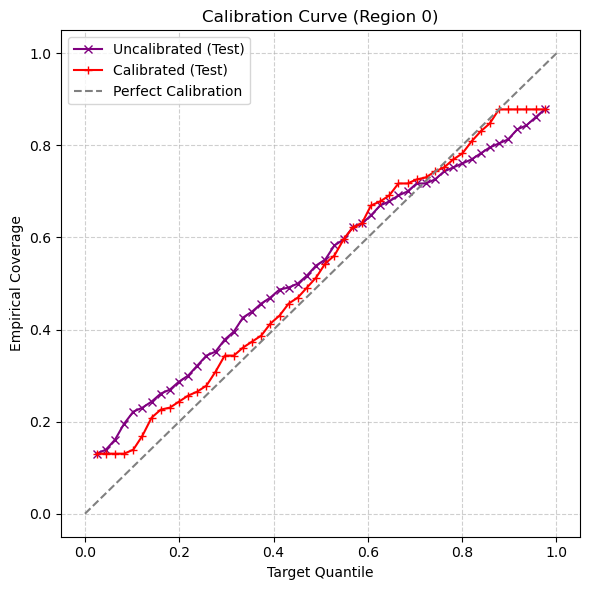

In [ ]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
    y_pred_test=y_pred.cpu().numpy(),
    y_pred_val=y_pred_cal.cpu().numpy(),
    Y_test=Y_test_array,
    Y_val=Y_cal_array,
    quantiles=robust_quantiles,
    plot_region=0,
)


In [ ]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.6025%
Mean MSCE (Calibrated Test): 0.2236%


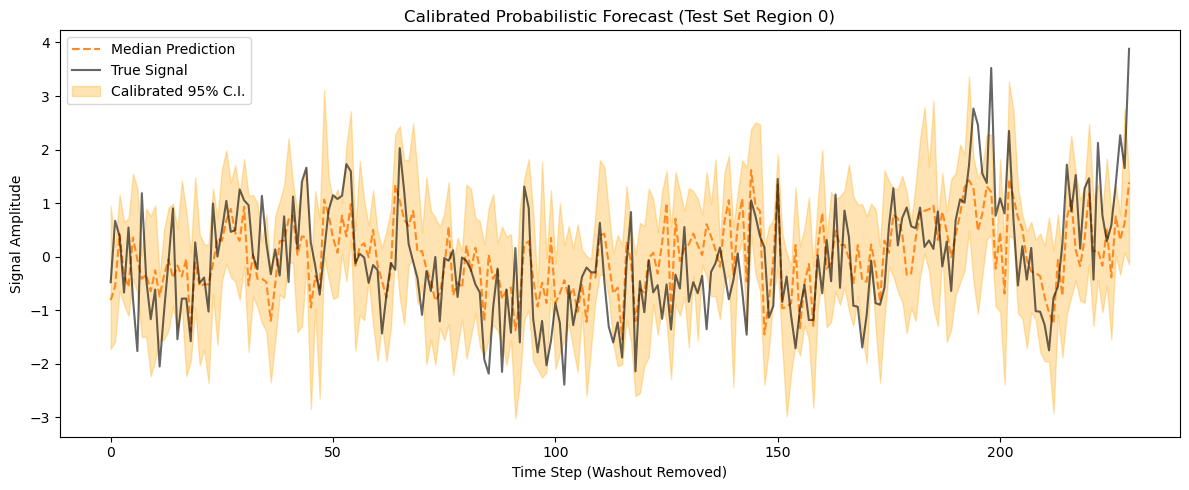

In [ ]:
plot_calibrated_test(
    Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles
)

## QR

Instead of relying on Bayesian inference, the authors of the paper suggested that other, more efficient methods could be implemented. One of them is a **deterministic approach** known as **Quantile Regression (QR)**.

We wanted to test and compare this method to see whether it could outperform the previous inference-based approaches.

Instead of predicting the expected mean by minimizing the Mean Squared Error (MSE), QR trains the readout layer to predict specific *quantiles* of the target distribution. This completely bypasses the dimensionality issues of the Reservoir and directly generates calibrated confidence intervals in a fraction of the computational time.

In QR the optimization problem is not the "standard" one in which we minimize the sum of squared residuals, but it is modified as follows:

$$\arg\min_{R(\tau)} \sum_{t=1}^{T} \rho_\tau \left( y_t - g(s_t; R(\tau)) \right)$$

Where $\rho_\tau$ is the **Pinball Loss (or Check Loss)**:

$$\rho_\tau(r) = \tau \max(r, 0) + (1-\tau)\max(-r, 0)$$

and $r = y_{true} - y_{pred}$ is the residual. By simultaneously optimizing this loss for $\tau = \{0.025, 0.50, 0.975\}$, the network learns to output the median and the bounds for the $95\%$ Confidence Interval directly, being able to infer a more detailed view of the distribution $P(Y|S)$, than just its mean value.

In [ ]:
taus = [0.025, 0.25, 0.5, 0.75, 0.975]
# Calculate the exact output size needed (e.g., 119 * 5 = 595)
num_quantiles = len(taus)
out_features = num_features_real * num_quantiles

# Update the linspace to target out_features
num_layers = 3
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, out_features, num_layers)
]

# Instantiate the model with the correct dimensions
qr_model_real = MLP(layer_dims, nn.Tanh()).to(device)

# Re-create your loss function and optimizer here...
loss_fn = CheckLoss(taus)
optimizer = torch.optim.Adam(qr_model_real.parameters(), lr=0.001)

# Re-instantiate the wrapper
esn_qr = ESNQR(qr_model_real, optimizer, loss_fn)

Training ESN:   1%|          | 3/400 [00:00<00:33, 12.01it/s, Loss=56.8759]

Epoch 0 | Total Loss: 60.3843


Training ESN:  26%|██▌       | 103/400 [00:07<00:20, 14.28it/s, Loss=24.6161]

Epoch 100 | Total Loss: 24.6369


Training ESN:  51%|█████     | 203/400 [00:14<00:13, 14.98it/s, Loss=24.2356]

Epoch 200 | Total Loss: 24.2431


Training ESN:  76%|███████▌  | 303/400 [00:20<00:06, 14.91it/s, Loss=23.6537]

Epoch 300 | Total Loss: 23.6741


Training ESN: 100%|██████████| 400/400 [00:27<00:00, 14.56it/s, Loss=22.7604]


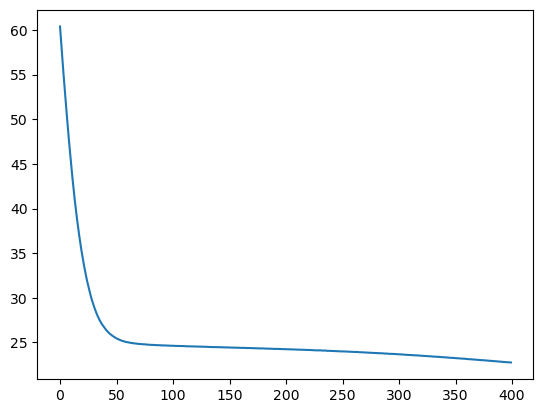

In [ ]:
EPOCHS = 400
loss_history = esn_qr.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [ ]:
y_pred = esn_qr.predict(test_set)
y_pred = y_pred.detach().cpu()

torch.Size([230, 5, 119])

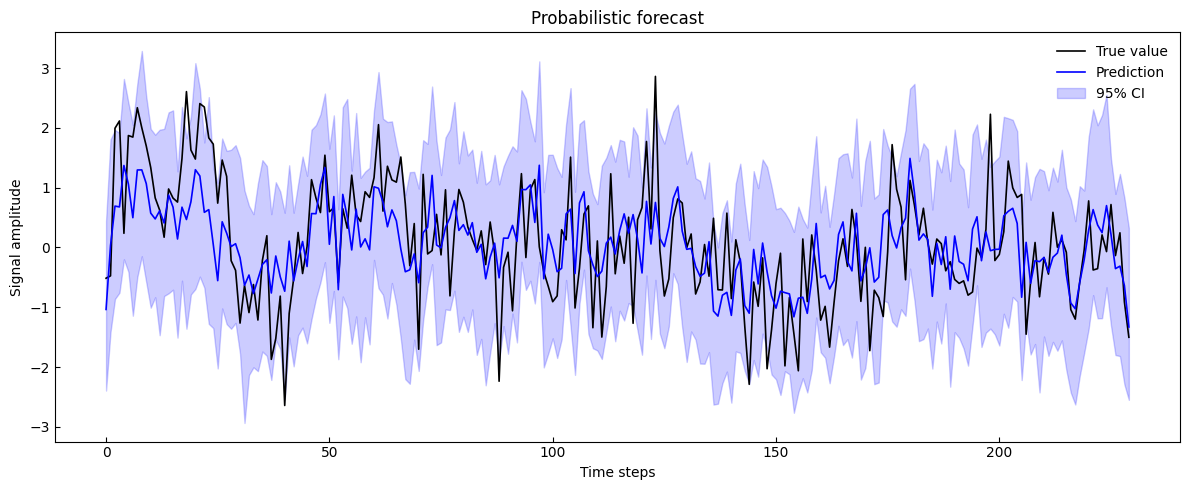

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0],
    y_pred=y_pred_mean[:, 0],
    y_lower=y_lower[:, 0],
    y_upper=y_upper[:, 0],
)

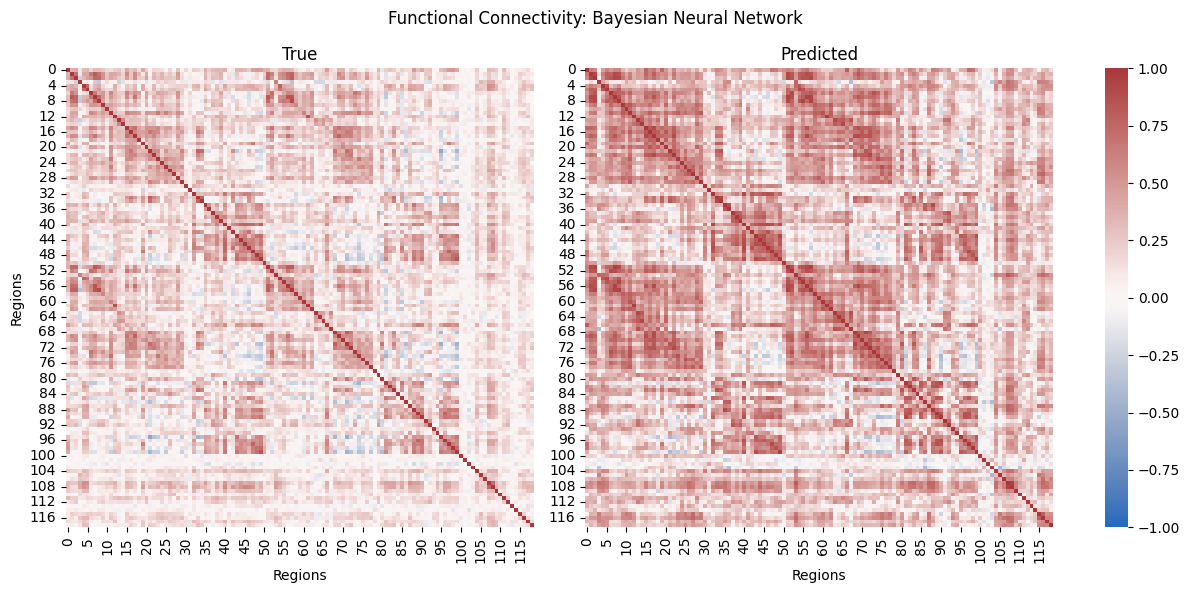

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(y_true_multi=y_true_np, y_pred_multi=y_pred_mean)

### metrics

In [ ]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics_qr(y_pred, test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_qr_real = evaluate_metrics_multiple(
    esn_obj=esn_qr,
    y_true=test_set.x.cpu(),
    test_set=test_set,
    model_type="QR",
    tau_levels=taus,
)

Empirical Coverage: 0.934 ± 0.002
Calibration Error:  0.00128 ± 0.00012
mCRPS (Normalized): 0.0620 ± 0.0009
Width: 2.827 ± 0.027


## Radial plot dict

In [ ]:
# Pack calculated dictionaries together
all_calculated_results = {
    "MCMC": dict_mcmc_real,
    "MCMC_PCA": dict_mcmc_pca_real,
    "SVI": dict_svi_real,
    "SSVS": dict_svss_real,
    "QR": dict_qr_real,
    "BNN": dict_bnn_real,
}

# Run the merger function
dict_radial_plot = combine_metrics_dictionaries(all_calculated_results)

In [ ]:
radial_plot(dict_radial_plot)

{'Cal': {'MCMC': [0.0036944912280887365,
   0.0038016585167497396,
   0.0036905971355736256,
   0.003674107836559415,
   0.0037054489366710186],
  'MCMC_PCA': [0.002555210143327713,
   0.002546978183090687,
   0.0024578412994742393,
   0.0025873868726193905,
   0.0026526988949626684],
  'SVI': [0.009187371470034122],
  'SSVS': [0.002606029622256756,
   0.002605322515591979,
   0.002515411702916026,
   0.0025908940006047487,
   0.0026112671475857496],
  'QR': [0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009],
  'BNN': [0.002287723822519183,
   0.0024395454674959183,
   0.0024502198211848736,
   0.0025574329774826765,
   0.0024696746841073036]},
 'Cov': {'MCMC': [0.7809280753135681,
   0.7808914184570312,
   0.7823163866996765,
   0.781914472579956,
   0.7796127200126648],
  'MCMC_PCA': [0.8148337602615356,
   0.8108147978782654,
   0.8135185837745667,
   0.8139934539794922,
   0.8111435770988464],
  'SVI': [0.